# RandomMeas.jl scalability benchmarks
This notebook provides **RandomMeas-only** scalability benchmarks (no comparisons to other libraries).

Sections:
1. **Simulation scaling**: time for `MeasurementGroup(ψ, settings, NM)` using an MPS.
2. **Post-processing scaling** on subsystem $A$: shadow construction, $K=5$ local Pauli observables, and trace moments.

Notes:
- Timings are machine-dependent; environment info is printed.
- For multi-second calls we use `@elapsed` (median over a small number of repeats).
- For sub-second kernels we use `@belapsed` from BenchmarkTools.


In [1]:

using Pkg, InteractiveUtils, LinearAlgebra, Statistics, Random, Dates, LsqFit

using BenchmarkTools, DataFrames, CSV, Plots

println("===== Environment =====")
versioninfo(verbose=false)
println("Threads: ", Threads.nthreads(), " | BLAS threads: ", BLAS.get_num_threads())
println()
Pkg.status()


===== Environment =====
Julia Version 1.12.4
Commit 01a2eadb047 (2026-01-06 16:56 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: macOS (arm64-apple-darwin24.0.0)
  CPU: 14 × Apple M4 Pro
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, apple-m4)
  GC: Built with stock GC
Threads: 8 default, 1 interactive, 8 GC (on 10 virtual cores)
Environment:
  JULIA_NUM_THREADS = 8
Threads: 8 | BLAS threads: 10

Project RandomMeas v0.3.0
Status `~/Andreas_Arbeit/Projects/RandomMeas.jl/Project.toml`
  [336ed68f] CSV v0.10.16
  [861a8166] Combinatorics v1.1.0
  [a93c6f00] DataFrames v1.8.1
⌃ [0d1a4710] ITensorMPS v0.3.25
⌃ [9136182c] ITensors v0.9.15
  [b964fa9f] LaTeXStrings v1.4.0
  [2fda8390] LsqFit v0.15.1
  [dde4c033] Metal v1.9.2
  [15e1cf62] NPZ v0.4.3
  [77e91f04] OptimKit v0.4.2
⌃ [91a5bcdd] Plots v1.41.2
  [92933f4c] ProgressMeter v1.11.0
  [189a3867] Reexport v1.2.2
⌃ [2913bbd2] StatsBase v0.34.9
  [c2297ded] ZMQ v1.5.1
  [e88e6eb3] Zygote v0.7.10
  [37e2e46d]

In [2]:

using RandomMeas
using ITensors
using ITensorMPS



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 0) Baseline parameters
Adjust here (or via ENV vars) to fit your machine.


In [3]:
# =========================
# Benchmark configuration
# =========================
# These defaults are chosen to run on a laptop in reasonable time.
# You can override any parameter via environment variables, e.g.:
#   RM_N=50 RM_NU=400 RM_NM=200 RM_CHI=8 julia --project -e 'include("...")'
#
# Interpretation:
#   N0   : total number of qubits in the full system
#   NU0  : number of randomized measurement settings (random local unitaries)
#   NM0  : number of projective measurement shots per setting
#   chi0 : MPS bond dimension (controls entanglement in the simulated state)
#
# Post-processing:
#   Kobs : number of local Pauli observables (on subsystem A) used in the observable-estimation benchmark
#   k_vec: trace-moment orders for polynomial functionals, e.g. [2,3,4] corresponds to Tr(ρ_A^k)
#
# Dense-batch shadows for moments:
#   nbatch_mom0 : number of RU-batches used to construct dense shadows for the trace-moment estimator.
#                This is a *runtime knob*: larger nbatch reduces estimator variance but increases compute cost.
#                A common heuristic is nbatch ≈ O(kmax) (we use 4*kmax here).
#
# Timing:
#   reps : number of repeats for multi-second measurements using @elapsed;
#          we report the median to reduce noise from GC / OS jitter.
# =========================

N0   = parse(Int, get(ENV, "RM_N",   "50"))
NU0  = parse(Int, get(ENV, "RM_NU",  "100"))
NM0  = parse(Int, get(ENV, "RM_NM",  "10"))
chi0 = parse(Int, get(ENV, "RM_CHI", "4"))

# Post-processing defaults
Kobs = parse(Int, get(ENV, "RM_KOBS", "5"))

k_vec = parse.(Int, split(get(ENV, "RM_KVEC", "2,3,4"), ","))
kmax = maximum(k_vec)

# Dense batching heuristic for moment estimation
nbatch_mom0 = parse(Int, get(ENV, "RM_NBATCH_MOM", string(4*kmax)))

# repeats for @elapsed sweeps (simulation stage)
reps = parse(Int, get(ENV, "RM_REPS", "2"))

# fixed RNG seed for reproducibility across runs
rng = MersenneTwister(1)

println("===== Baseline config =====")
println("System: N0=$N0 qubits | MPS bond dimension chi0=$chi0")
println("Measurements: NU0=$NU0 settings | NM0=$NM0 shots/setting")
println("Observables benchmark: Kobs=$Kobs local Pauli strings on A")
println("Moments benchmark: k_vec=$k_vec (kmax=$kmax) | nbatch_mom0=$nbatch_mom0 dense RU-batches")
println("Timing: reps=$reps (median @elapsed for multi-second sweeps)")

===== Baseline config =====
System: N0=50 qubits | MPS bond dimension chi0=4
Measurements: NU0=100 settings | NM0=10 shots/setting
Observables benchmark: Kobs=5 local Pauli strings on A
Moments benchmark: k_vec=[2, 3, 4] (kmax=4) | nbatch_mom0=16 dense RU-batches
Timing: reps=2 (median @elapsed for multi-second sweeps)


## Helper: median timing for expensive calls
(Kept minimal; used for the `MeasurementGroup` sweeps.)


In [4]:

function tmedian_elapsed(f; reps::Int=2)
    ts = Float64[]
    for _ in 1:reps
        GC.gc()
        push!(ts, @elapsed f())
    end
    return median(ts), ts
end


tmedian_elapsed (generic function with 1 method)

## 1) Simulation scaling: `MeasurementGroup(ψ, settings, NM)`
We sweep one parameter at a time. This corresponds to the MPS-based simulation used for Fig. 2.


In [5]:

function time_measurementgroup(N::Int, NU::Int, NM::Int, chi::Int; reps::Int=2)
    settings = [LocalUnitaryMeasurementSetting(N) for _ in 1:NU]
    sites = siteinds("Qubit", N)
    ψ = random_mps(sites; linkdims=chi)
    tmed, ts = tmedian_elapsed(() -> MeasurementGroup(ψ, settings, NM); reps=reps)
    return tmed, ts
end


time_measurementgroup (generic function with 1 method)

### 1a) Sweep in N (log-log plot)


In [ ]:

Ns = parse.(Int, split(get(ENV, "RM_SWEEP_N", "20,30,40,50,60,70,80, 100, 200"), ","))

#warm up run
_,_ = time_measurementgroup(1,1,1,1; reps=1)

dfN = DataFrame(N=Int[], t=Float64[])
for N in Ns
    tmed, ts = time_measurementgroup(N, NU0, NM0, chi0; reps=reps)
    push!(dfN, (N, tmed))
    println("N=$N -> t≈$(round(tmed,digits=3)) s   runs=$(round.(ts,digits=3))"); flush(stdout)
end
dfN


N=20 -> t≈4.142 s   runs=[7.662, 0.623]
N=30 -> t≈0.964 s   runs=[0.987, 0.94]
N=40 -> t≈1.315 s   runs=[1.328, 1.302]
N=50 -> t≈1.723 s   runs=[1.718, 1.728]
N=60 -> t≈2.174 s   runs=[2.175, 2.172]
N=70 -> t≈2.618 s   runs=[2.617, 2.619]
N=80 -> t≈3.133 s   runs=[3.141, 3.126]


Row,N,t
,Int64,Float64
1,20,4.14238
2,30,0.963731
3,40,1.31512
4,50,1.72299
5,60,2.17361
6,70,2.61791
7,80,3.13349


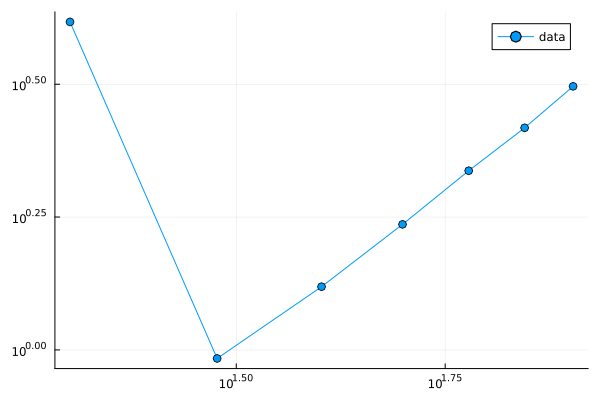

In [25]:
plot(dfN.N, dfN.t; marker=:o, xscale=:log10, yscale=:log10, label="data")


### 1b) Sweep in bond dimension χ (log-log plot)


In [8]:

chis = parse.(Int, split(get(ENV, "RM_SWEEP_CHI", "8, 16,24, 32, 40, 48, 56, 64, 72, 80, 100, 120,140 "), ","))

dfChi = DataFrame(chi=Int[], t=Float64[])
for chi in chis
    tmed, ts = time_measurementgroup(N0, NU0, NM0, chi; reps=reps)
    push!(dfChi, (chi, tmed))
    println("chi=$chi -> t≈$(round(tmed,digits=3)) s   runs=$(round.(ts,digits=3))"); flush(stdout)
end
dfChi


chi=8 -> t≈1.905 s   runs=[1.963, 1.848]
chi=16 -> t≈2.192 s   runs=[2.194, 2.189]
chi=24 -> t≈2.389 s   runs=[2.337, 2.441]
chi=32 -> t≈3.16 s   runs=[3.122, 3.199]
chi=40 -> t≈3.855 s   runs=[3.855, 3.855]
chi=48 -> t≈5.007 s   runs=[5.096, 4.918]
chi=56 -> t≈5.851 s   runs=[5.868, 5.834]
chi=64 -> t≈7.366 s   runs=[7.194, 7.538]
chi=72 -> t≈9.684 s   runs=[9.282, 10.085]
chi=80 -> t≈12.005 s   runs=[12.486, 11.524]
chi=100 -> t≈17.748 s   runs=[17.893, 17.604]
chi=120 -> t≈25.997 s   runs=[25.764, 26.229]
chi=140 -> t≈39.764 s   runs=[41.252, 38.276]


Row,chi,t
,Int64,Float64
1,8,1.90547
2,16,2.19151
3,24,2.3891
4,32,3.16006
5,40,3.85467
6,48,5.00698
7,56,5.85095
8,64,7.36582
9,72,9.68379


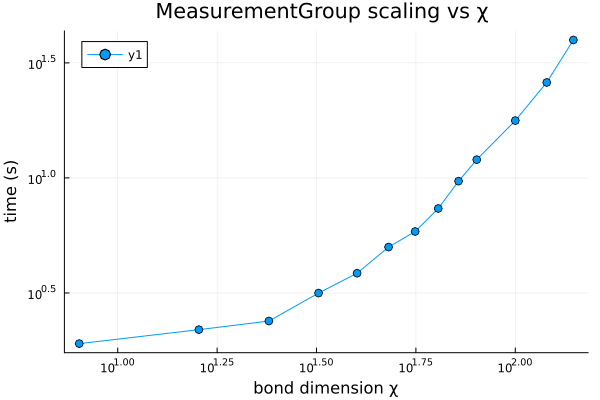

In [9]:
plot(dfChi.chi, dfChi.t; marker=:o , xscale=:log10, yscale=:log10,
     xlabel="bond dimension χ", ylabel="time (s)",
     title="MeasurementGroup scaling vs χ ")


### 1c) Sweep in NU (linear plot)


In [10]:

NUs = parse.(Int, split(get(ENV, "RM_SWEEP_NU", "50,100, 150,200, 250, 300, 350, 400"), ","))

dfNU = DataFrame(NU=Int[], t=Float64[])
for NU in NUs
    tmed, ts = time_measurementgroup(N0, NU, NM0, chi0; reps=reps)
    push!(dfNU, (NU, tmed))
    println("NU=$NU -> t≈$(round(tmed,digits=3)) s   runs=$(round.(ts,digits=3))"); flush(stdout)
end
dfNU


NU=50 -> t≈0.813 s   runs=[0.818, 0.808]
NU=100 -> t≈1.73 s   runs=[1.731, 1.729]
NU=150 -> t≈2.646 s   runs=[2.644, 2.648]
NU=200 -> t≈3.571 s   runs=[3.556, 3.586]
NU=250 -> t≈4.478 s   runs=[4.467, 4.489]
NU=300 -> t≈5.452 s   runs=[5.432, 5.472]
NU=350 -> t≈6.374 s   runs=[6.359, 6.39]
NU=400 -> t≈7.312 s   runs=[7.317, 7.307]


Row,NU,t
,Int64,Float64
1,50,0.812982
2,100,1.72973
3,150,2.64588
4,200,3.57097
5,250,4.47799
6,300,5.45221
7,350,6.37442
8,400,7.31187


In [ ]:
plot(dfNU.NU, dfNU.t; marker=:o, 
     xlabel="NU", ylabel="time (s)",
     title="MeasurementGroup scaling vs vs NU")



UndefVarError: UndefVarError: `t` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### 1d) Sweep in NM (linear plot)


In [12]:

NMs = parse.(Int, split(get(ENV, "RM_SWEEP_NM", "50,100, 150,200, 250"), ","))

dfNM = DataFrame(NM=Int[], t=Float64[])
for NM in NMs
    tmed, ts = time_measurementgroup(N0, NU0, NM, chi0; reps=reps)
    push!(dfNM, (NM, tmed))
    println("NM=$NM -> t≈$(round(tmed,digits=3)) s   runs=$(round.(ts,digits=3))"); flush(stdout)
end
dfNM


NM=50 -> t≈4.493 s   runs=[4.497, 4.489]
NM=100 -> t≈7.671 s   runs=[7.674, 7.668]
NM=150 -> t≈11.049 s   runs=[11.061, 11.037]
NM=200 -> t≈14.184 s   runs=[14.168, 14.2]
NM=250 -> t≈17.586 s   runs=[17.613, 17.558]


Row,NM,t
,Int64,Float64
1,50,4.49318
2,100,7.67061
3,150,11.0486
4,200,14.1838
5,250,17.5856


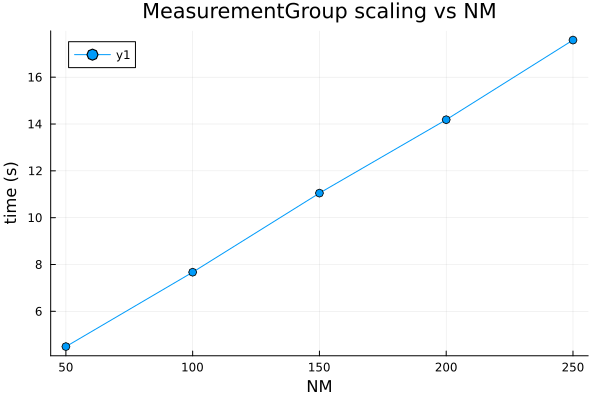

In [13]:

plot(dfNM.NM, dfNM.t; marker=:o, 
     xlabel="NM", ylabel="time (s)",
     title="MeasurementGroup scaling vs NM")


## 2) Post-processing scaling on subsystem A
We generate one baseline dataset once, then benchmark:
- shadow construction vs NA (factorized and dense with 1 RU batch)
- observable estimation (K=5) vs NA (estimator only)
- trace moments vs NA (capped; dense uses `nbatch≈5*kmax`)


### 2.0) Build one baseline `MeasurementGroup` once


In [15]:

settings_base = [LocalUnitaryMeasurementSetting(N0) for _ in 1:NU0]
sites_base = siteinds("Qubit", N0)
ψ_base = random_mps(sites_base; linkdims=chi0)

println("Building baseline MeasurementGroup once.")
GC.gc()
t_base = @elapsed mg_base = MeasurementGroup(ψ_base, settings_base, NM0)
println("Baseline MeasurementGroup time: $(round(t_base,digits=3)) s")


Building baseline MeasurementGroup once.
Baseline MeasurementGroup time: 1.753 s


### 2a) Shadow construction vs NA (factorized + dense(1 batch))


In [16]:
ITensors.disable_warn_order()

NAs_build = parse.(Int, split(get(ENV, "RM_SWEEP_NA_BUILD", "2,4,6,8,10"), ","))

dfBuild = DataFrame(NA=Int[],
                    t_build_F=Float64[], t_build_D1=Float64[],
                    mem_F_MiB=Float64[], mem_D1_MiB=Float64[])

for NA in NAs_build
    mgA = reduce_to_subsystem(mg_base, collect(1:NA))

    # timings
    _ = get_factorized_shadows(mgA); GC.gc()
    tF  = @belapsed get_factorized_shadows($mgA)

    _ = get_dense_shadows(mgA; number_of_ru_batches=1); GC.gc()
    tD1 = @belapsed get_dense_shadows($mgA; number_of_ru_batches=1)

    # build once to measure memory
    shF = get_factorized_shadows(mgA)
    shD1 = get_dense_shadows(mgA; number_of_ru_batches=1)[1]

    memF  = Base.summarysize(shF)  / 2.0^20
    memD1 = Base.summarysize(shD1) / 2.0^20

    push!(dfBuild, (NA, tF, tD1, memF, memD1))
    println("NA=$NA | buildF=$(round(tF,digits=4))s  buildD1=$(round(tD1,digits=4))s"
            * " | memF=$(round(memF,digits=2)) MiB  memD1=$(round(memD1,digits=2)) MiB"); flush(stdout)
end

dfBuild


NA=2 | buildF=0.0103s  buildD1=0.0034s | memF=1.46 MiB  memD1=0.0 MiB
NA=4 | buildF=0.0205s  buildD1=0.0086s | memF=2.82 MiB  memD1=0.01 MiB
NA=6 | buildF=0.0313s  buildD1=0.0363s | memF=4.17 MiB  memD1=0.07 MiB
NA=8 | buildF=0.0423s  buildD1=0.2872s | memF=5.53 MiB  memD1=1.0 MiB
NA=10 | buildF=0.0558s  buildD1=4.8661s | memF=6.89 MiB  memD1=16.01 MiB


Row,NA,t_build_F,t_build_D1,mem_F_MiB,mem_D1_MiB
,Int64,Float64,Float64,Float64,Float64
1,2,0.0103275,0.00340046,1.45726,0.00146484
2,4,0.0205075,0.008628,2.81529,0.00622559
3,6,0.0312587,0.036285,4.17332,0.065918
4,8,0.0423008,0.287214,5.53136,1.00452
5,10,0.0557527,4.86608,6.88939,16.0056


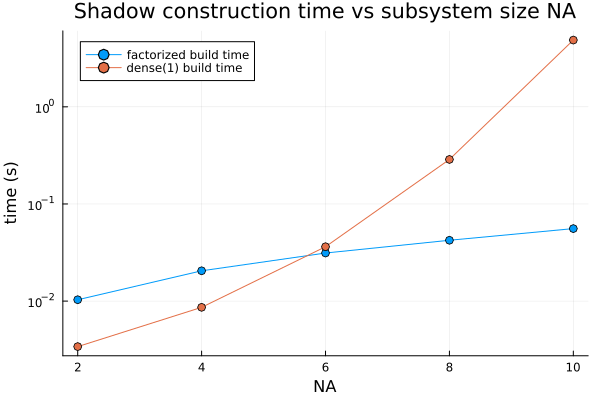

In [17]:
plot(dfBuild.NA, dfBuild.t_build_F; marker=:o, label="factorized build time")
plot!(dfBuild.NA, dfBuild.t_build_D1; marker=:o, label="dense(1) build time")
plot!(xlabel="NA", ylabel="time (s)", yscale=:log10,
      title="Shadow construction time vs subsystem size NA")


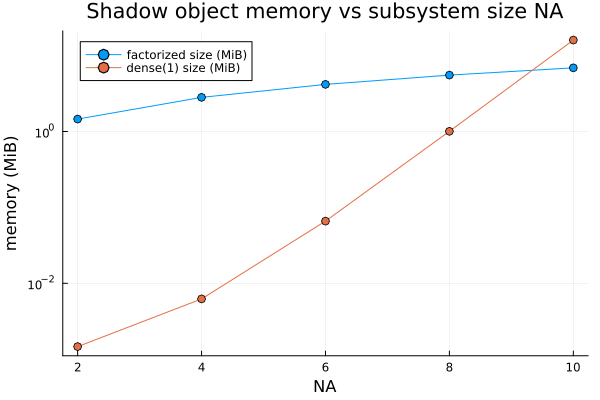

In [18]:
plot(dfBuild.NA, dfBuild.mem_F_MiB; marker=:o, label="factorized size (MiB)")
plot!(dfBuild.NA, dfBuild.mem_D1_MiB; marker=:o, label="dense(1) size (MiB)")
plot!(xlabel="NA", ylabel="memory (MiB)", yscale=:log10,
      title="Shadow object memory vs subsystem size NA")

### 2b) Observable estimation vs NA (K=5, estimator only)
We do **not** benchmark shadow construction here (only the estimator runtime).

In [19]:

# Global estimator helper (BenchmarkTools macro scope)
sumK(shadow, ops) = begin
    s = 0.0
    @inbounds for O in ops
        s += real(get_expect_shadow(O, shadow))
    end
    s
end

# Minimal MPO generator for random Pauli strings on subsystem A
function random_pauli_mpos(rng::AbstractRNG, siteinds::Vector{Index{Int}}, K::Int; p_identity=0.5)
    N = length(siteinds)
    out = Vector{MPO}(undef, K)
    for k in 1:K
        ops = Vector{String}(undef, N)
        for j in 1:N
            if rand(rng) < p_identity
                ops[j] = "I"
            else
                ops[j] = rand(rng, ("X","Y","Z"))
            end
        end
        out[k] = MPO(ComplexF64, siteinds, ops)  # Complex needed for Y
    end
    return out
end


random_pauli_mpos (generic function with 1 method)

In [20]:

NAs_obs = parse.(Int, split(get(ENV, "RM_SWEEP_NA_OBS", "4,6,8,10,12"), ","))

dfObs = DataFrame(NA=Int[], t_obs_F=Float64[], t_obs_D=Float64[])

for NA in NAs_obs
    mgA = reduce_to_subsystem(mg_base, collect(1:NA))

    # Construct shadows (no timing here)
    shF = get_factorized_shadows(mgA)
    shD = get_dense_shadows(mgA; number_of_ru_batches=1)[1]

    siteA = mgA.measurements[1].measurement_setting.site_indices
    ops = random_pauli_mpos(rng, siteA, Kobs; p_identity=0.5)

    # Warmup to compile any missing methods
    sumK(shF, ops); sumK(shD, ops)


    GC.gc()
    tF = @belapsed sumK($shF, $ops)

    GC.gc()
    tD = @belapsed sumK($shD, $ops)

    push!(dfObs, (NA, tF, tD))
    println("NA=$NA | obsF=$(round(tF,digits=6))s  obsD=$(round(tD,digits=6))s"); flush(stdout)
end

dfObs


NA=4 | obsF=0.114856s  obsD=0.000107s
NA=6 | obsF=0.177408s  obsD=0.000282s
NA=8 | obsF=0.263438s  obsD=0.00182s
NA=10 | obsF=0.331741s  obsD=0.029871s
NA=12 | obsF=0.363288s  obsD=0.520698s


Row,NA,t_obs_F,t_obs_D
,Int64,Float64,Float64
1,4,0.114856,0.000107125
2,6,0.177408,0.000282459
3,8,0.263438,0.00181967
4,10,0.331741,0.0298706
5,12,0.363288,0.520698


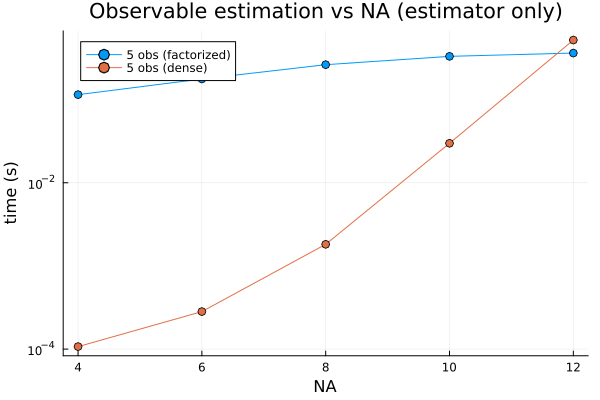

In [21]:
plot(dfObs.NA, dfObs.t_obs_F;yscale=:log10, marker=:o, label="$(Kobs) obs (factorized)")
plot!(dfObs.NA, dfObs.t_obs_D; yscale=:log10, marker=:o, label="$(Kobs) obs (dense)")
plot!(xlabel="NA", ylabel="time (s)", title="Observable estimation vs NA (estimator only)")


### 2c) Trace moments vs NA
This is typically expensive due to U-statistic combinatorics. Default NA sweep is 4,6,8.

For dense shadows, `get_dense_shadows` returns a vector of length `nbatch`; we pass it to `get_trace_moments`
as a `(nbatch,1)` array via `reshape`.


In [22]:
NAs_mom = parse.(Int, split(get(ENV, "RM_SWEEP_NA_MOM", "3,4,5,6"), ","))

dfMom = DataFrame(NA=Int[], nbatch=Int[], t_mom_D=Float64[])

# Warmup (compile) once
mgA = reduce_to_subsystem(mg_base, collect(1:2))
nb = min(nbatch_mom0, mgA.NU)
shD = get_dense_shadows(mgA; number_of_ru_batches=nb)
get_trace_moments(shD, k_vec)

for NA in NAs_mom
    mgA = reduce_to_subsystem(mg_base, collect(1:NA))

    nb = min(nbatch_mom0, mgA.NU)
    shD = get_dense_shadows(mgA; number_of_ru_batches=nb)

    # Time (median of a few @elapsed runs)
    tmed, ts = tmedian_elapsed(() -> get_trace_moments(shD, k_vec); reps=reps)

    push!(dfMom, (NA, nb, tmed))
    println("NA=$NA | nbatch=$nb | momD≈$(round(tmed,digits=4))s   runs=$(round.(ts,digits=4))"); flush(stdout)
end

dfMom


NA=3 | nbatch=16 | momD≈3.634s   runs=[4.181, 3.0871]
NA=4 | nbatch=16 | momD≈4.7601s   runs=[5.381, 4.1393]
NA=5 | nbatch=16 | momD≈9.6687s   runs=[10.316, 9.0214]
NA=6 | nbatch=16 | momD≈26.5895s   runs=[27.1772, 26.0019]


Row,NA,nbatch,t_mom_D
,Int64,Int64,Float64
1,3,16,3.63405
2,4,16,4.76015
3,5,16,9.66868
4,6,16,26.5895


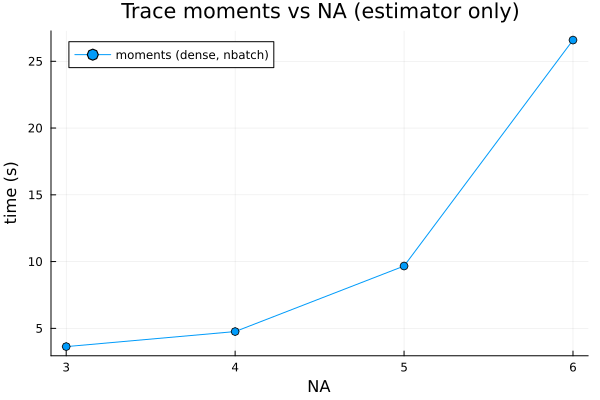

In [23]:
plot(dfMom.NA, dfMom.t_mom_D; marker=:o, label="moments (dense, nbatch)")
plot!(xlabel="NA", ylabel="time (s)", title="Trace moments vs NA (estimator only)")